# Task 3: Clustering Analysis

**Index:**
1. Load Engineered Data
2. K-Means Clustering
3. Hierarchical Clustering
4. Gaussian Mixture Models (GMM)

In [1]:
import sys
import os

# Add project root to path so src can be imported
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import clustering utilities
from src.clustering import (
    evaluate_clustering,
    plot_cluster_scatter,
    plot_algorithm_comparison,
    compare_clusters_to_classes,
)

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

# Ensure plots directory exists
os.makedirs(os.path.join(project_root, "data", "plots"), exist_ok=True)

## 1. Load Engineered Data

In [2]:
# Load engineered train/val/test data and concatenate to full dataset
features_train = pd.read_csv(os.path.join(project_root, 'data', 'features_engineered_train.csv'))
targets_train = pd.read_csv(os.path.join(project_root, 'data', 'targets_engineered_train.csv')).iloc[:, 0]

features_val = pd.read_csv(os.path.join(project_root, 'data', 'features_engineered_val.csv'))
targets_val = pd.read_csv(os.path.join(project_root, 'data', 'targets_engineered_val.csv')).iloc[:, 0]

features_test = pd.read_csv(os.path.join(project_root, 'data', 'features_engineered_test.csv'))
targets_test = pd.read_csv(os.path.join(project_root, 'data', 'targets_engineered_test.csv')).iloc[:, 0]

# Concatenate to full dataset
X = pd.concat([features_train, features_val, features_test], axis=0, ignore_index=True)
y = pd.concat([targets_train, targets_val, targets_test], axis=0, ignore_index=True)

print(f"Features shape: {X.shape}")
print(f"Target distribution:")
print(y.value_counts().sort_index().to_string())

Features shape: (4424, 40)
Target distribution:
Target
0    1421
1     794
2    2209


In [3]:
# Compute 2D t-SNE for visualization 
from src.visualization import (
    compute_tsne,
    plot_tsne_2d,
    plot_tsne_2d_multi
)

perp = 30
tsne_embedding = compute_tsne(X.values, perplexity=perp, n_components=2)
print(tsne_embedding.shape)

t-SNE done: perplexity=30, n_components=2, shape=(4424, 2)
(4424, 2)


Three clustering algorithms with distinct assumptions are selected:

1. **K-Means**
2. **Agglomerative Hierarchical**
3. **GMM**

## 2.0 t-SNE scatter colored by true class

t-SNE done: perplexity=30, n_components=2, shape=(4424, 2)
Plot saved to /media/appleblue17/E/vscode/Assignments/2026Spring/ML/2026.04.27 Final Project/dsaa2011_machine_learning/data/plots/03_tsne_perp_30.png


<Axes: title={'center': 't-SNE Projection (p=30)'}, xlabel='Dimension 1', ylabel='Dimension 2'>

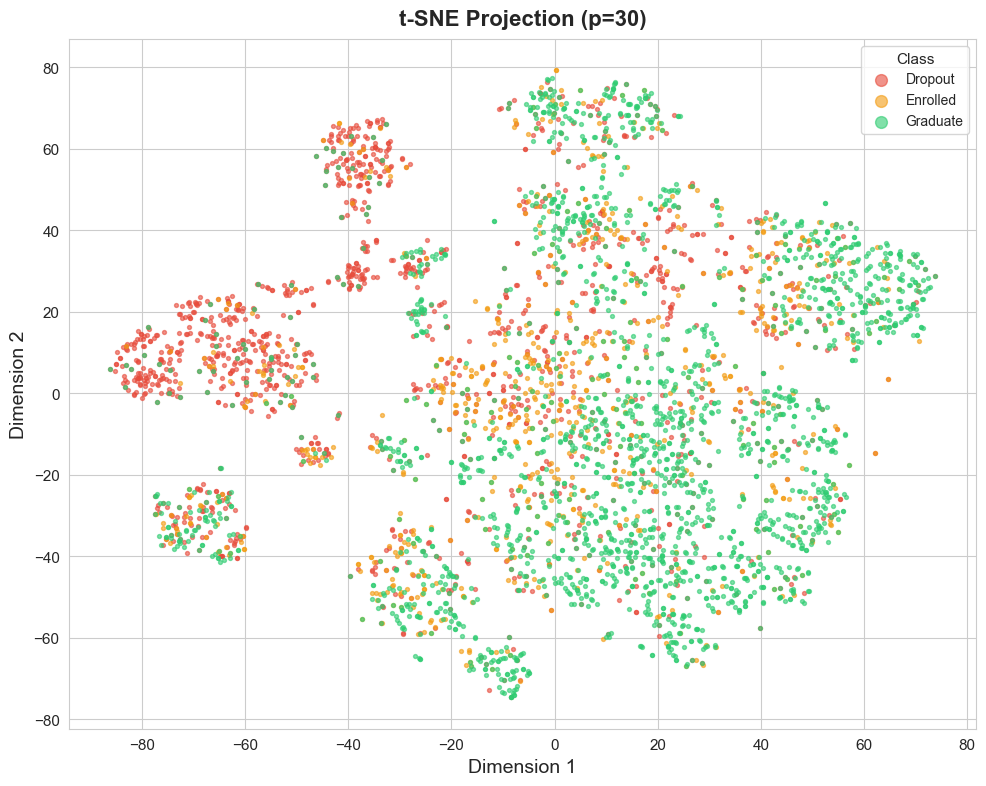

In [4]:
embedding = compute_tsne(X.values, perplexity=perp, n_components=2)
plot_tsne_2d(
	embedding, 
	labels=y, 
	save_path=os.path.join(project_root, "data", "plots", f"03_tsne_perp_{perp}.png")
)

## 2.1 K-Means K-Value Exploration

We explore larger K values (K=3,4,5,6) to determine whether splitting classes into more clusters improves alignment with true labels. While K=3 matches the number of target classes, the target-encoded features may benefit from additional cluster granularity.

In [5]:
# K-Means K-Value Exploration
from sklearn.cluster import KMeans

print("K-Means K-Value Exploration:")
print(f"{'K':>3} | {'ARI':>8} | {'NMI':>8} | {'Silhouette':>10} | {'CH Index':>10} | {'DB Index':>10}")
print("-" * 65)

kmeans_results = {}
for k in range(3,20):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X.values)
    metrics = evaluate_clustering(X.values, labels, y.values)
    kmeans_results[k] = {"labels": labels, "metrics": metrics}
    print(f"{k:>3} | {metrics.get('adjusted_rand_index', 0):>8.4f} | {metrics.get('normalized_mutual_info', 0):>8.4f} | {metrics.get('silhouette', 0):>10.4f} | {metrics.get('calinski_harabasz', 0):>10.2f} | {metrics.get('davies_bouldin', 0):>10.4f}")

K-Means K-Value Exploration:
  K |      ARI |      NMI | Silhouette |   CH Index |   DB Index
-----------------------------------------------------------------
  3 |   0.1301 |   0.1198 |     0.2722 |     848.80 |     1.5689
  4 |   0.2313 |   0.1559 |     0.1734 |     729.24 |     2.0620
  5 |   0.2004 |   0.1486 |     0.1422 |     629.19 |     2.2165
  6 |   0.1544 |   0.1306 |     0.1246 |     576.00 |     1.9510
  7 |   0.1402 |   0.1276 |     0.1331 |     538.83 |     1.9051
  8 |   0.1385 |   0.1305 |     0.1252 |     507.57 |     1.8808
  9 |   0.0885 |   0.1106 |     0.1243 |     476.50 |     1.9333
 10 |   0.0888 |   0.1148 |     0.1174 |     463.97 |     1.9158
 11 |   0.0800 |   0.1122 |     0.1162 |     436.84 |     2.0156
 12 |   0.0610 |   0.1081 |     0.1022 |     410.54 |     2.0780
 13 |   0.0622 |   0.1049 |     0.1056 |     391.44 |     1.9172
 14 |   0.0745 |   0.1108 |     0.1177 |     373.78 |     1.8939
 15 |   0.0534 |   0.1039 |     0.1035 |     358.95 |     2.

## 2.2 K-Means Detailed Analysis

K-Means (K=4) Metrics:
  silhouette: 0.1734
  silhouette_std: 0.1220
  calinski_harabasz: 729.2408
  davies_bouldin: 2.0620
  noise_ratio: 0.0000
  adjusted_rand_index: 0.2313
  normalized_mutual_info: 0.1559

K-Means Cluster Size Distribution:
 Cluster  Count  Percentage
       0   1062        24.0
       1   2371        53.6
       2    738        16.7
       3    253         5.7

K-Means Clusters vs True Classes:
True Class    0    1     2
Cluster                   
0           525  326   211
1           310  352  1709
2           528   80   130
3            58   36   159

Dominant Class per Cluster:
  Cluster 0: Dropout (49.4%)
  Cluster 1: Graduate (72.1%)
  Cluster 2: Dropout (71.5%)
  Cluster 3: Graduate (62.8%)
Plot saved to /media/appleblue17/E/vscode/Assignments/2026Spring/ML/2026.04.27 Final Project/dsaa2011_machine_learning/data/plots/03_kmeans_clusters_tsne.png


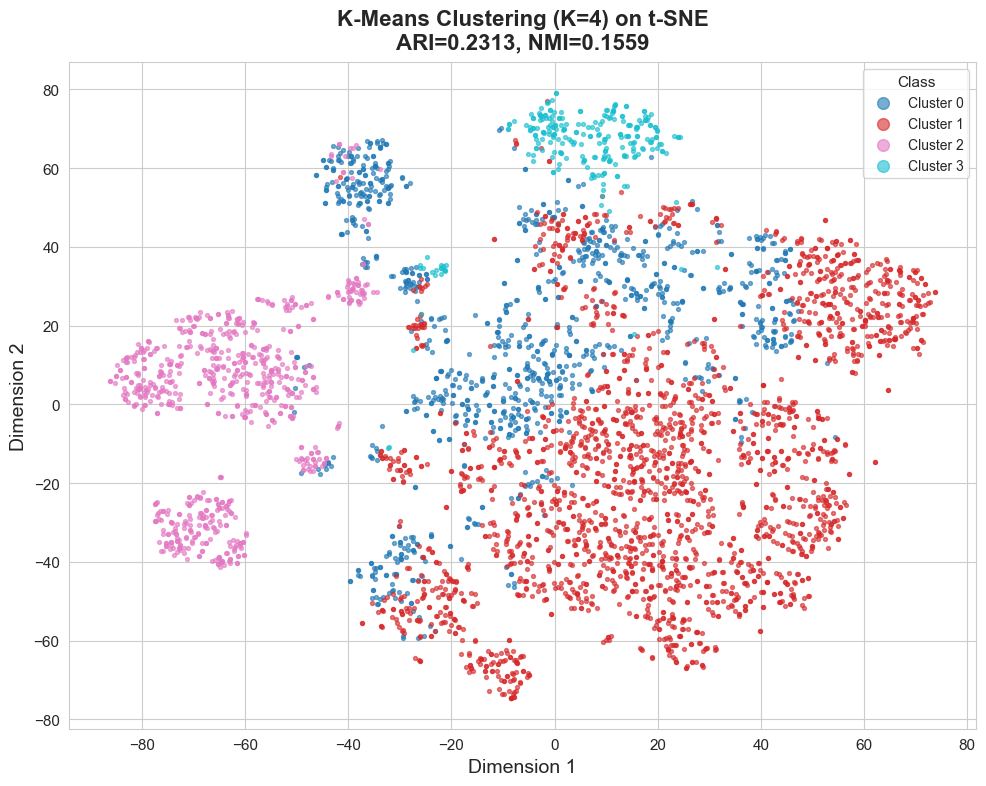

In [6]:
# K-Means Detailed Analysis (t-SNE visualization)

best_k = 4
kmeans_labels = kmeans_results[best_k]["labels"]
kmeans_metrics = kmeans_results[best_k]["metrics"]

# Update optimal_k for later comparison section
optimal_k = best_k

print(f"K-Means (K={best_k}) Metrics:")
for name, value in kmeans_metrics.items():
    print(f"  {name}: {value:.4f}" if isinstance(value, float) else f"  {name}: {value}")

# K-Means K=4 cluster size distribution
kmeans4_cluster_sizes = pd.Series(kmeans_labels).value_counts().sort_index()
kmeans4_size_df = pd.DataFrame({
    "Cluster": kmeans4_cluster_sizes.index,
    "Count": kmeans4_cluster_sizes.values,
    "Percentage": (kmeans4_cluster_sizes.values / len(kmeans_labels) * 100).round(1)
})
print("\nK-Means Cluster Size Distribution:")
print(kmeans4_size_df.to_string(index=False))

# K-Means K=4 cross-tabulation
class_names = {0: "Dropout", 1: "Enrolled", 2: "Graduate"}
kmeans4_crosstab = compare_clusters_to_classes(kmeans_labels, y.values)
print("\nK-Means Clusters vs True Classes:")
print(kmeans4_crosstab.to_string())

print("\nDominant Class per Cluster:")
for cluster in kmeans4_crosstab.index:
    row = kmeans4_crosstab.loc[cluster]
    dominant_class = row.idxmax()
    dominant_pct = row.max() / row.sum() * 100
    print(f"  Cluster {cluster}: {class_names[dominant_class]} ({dominant_pct:.1f}%)")

# t-SNE visualization for K-Means K=4 clusters
from src.visualization import compute_tsne, plot_tsne_2d

# Plot t-SNE with cluster labels
save_path = os.path.join(project_root, "data", "plots", "03_kmeans_clusters_tsne.png")
ax = plot_tsne_2d_multi(
    tsne_embedding, kmeans_labels,
    title=f"K-Means Clustering (K={best_k}) on t-SNE\nARI={kmeans_metrics['adjusted_rand_index']:.4f}, NMI={kmeans_metrics['normalized_mutual_info']:.4f}",
    save_path=save_path
)
plt.show()

## 3.1 Hierarchical Linkage Method and K-Value Exploration

We first compare different linkage methods (ward, complete, average, single) with K=3 to select the best one.

We then explore different K values (K=3,4,5,6) for Hierarchical Clustering with Ward linkage.

In [7]:
# Hierarchical Linkage Comparison (K=3)
from sklearn.cluster import AgglomerativeClustering

print("Hierarchical Linkage Comparison (K=3):")
print(f"{'Method':>12} | {'ARI':>8} | {'NMI':>8} | {'Silhouette':>10} | {'CH Index':>10} | {'DB Index':>10}")
print("-" * 65)

linkage_results = {}
best_linkage = None
best_linkage_ari = 0

for method in ['ward', 'complete', 'average', 'single']:
    agg = AgglomerativeClustering(n_clusters=3, linkage=method)
    labels = agg.fit_predict(X.values)
    metrics = evaluate_clustering(X.values, labels, y.values)
    linkage_results[method] = {"labels": labels, "metrics": metrics}
    ari = metrics.get('adjusted_rand_index', 0)
    nmi = metrics.get('normalized_mutual_info', 0)
    sil = metrics.get('silhouette', 0)
    ch = metrics.get('calinski_harabasz', 0)
    db = metrics.get('davies_bouldin', 0)
    print(f"{method:>12} | {ari:>8.4f} | {nmi:>8.4f} | {sil:>10.4f} | {ch:>10.2f} | {db:>10.4f}")
    if ari > best_linkage_ari:
        best_linkage_ari = ari
        best_linkage = method

print(f"\nBest linkage: {best_linkage} (ARI={best_linkage_ari:.4f})")

Hierarchical Linkage Comparison (K=3):
      Method |      ARI |      NMI | Silhouette |   CH Index |   DB Index
-----------------------------------------------------------------
        ward |   0.1332 |   0.1187 |     0.2538 |     772.45 |     1.6391
    complete |  -0.0084 |   0.0054 |     0.2697 |     183.47 |     1.2513
     average |   0.0009 |   0.0022 |     0.5365 |      21.99 |     0.7109
      single |   0.0002 |   0.0010 |     0.5280 |       7.45 |     0.3468

Best linkage: ward (ARI=0.1332)


In [8]:
# Hierarchical Clustering K-Value Exploration (using best linkage: ward)
print(f"Hierarchical Clustering K-Value Exploration (linkage={best_linkage}):")
print(f"{'K':>3} | {'ARI':>8} | {'NMI':>8} | {'Silhouette':>10} | {'CH Index':>10} | {'DB Index':>10}")
print("-" * 65)

hierarchical_results = {}
for k in [3, 4, 5, 6]:
    agg = AgglomerativeClustering(n_clusters=k, linkage=best_linkage)
    labels = agg.fit_predict(X.values)
    metrics = evaluate_clustering(X.values, labels, y.values)
    hierarchical_results[k] = {"labels": labels, "metrics": metrics}
    print(f"{k:>3} | {metrics.get('adjusted_rand_index', 0):>8.4f} | {metrics.get('normalized_mutual_info', 0):>8.4f} | {metrics.get('silhouette', 0):>10.4f} | {metrics.get('calinski_harabasz', 0):>10.2f} | {metrics.get('davies_bouldin', 0):>10.4f}")

best_hier_k = 3  # K=3 has best ARI among hierarchical results
print(f"\nBest K for Hierarchical: {best_hier_k} (ARI={hierarchical_results[best_hier_k]['metrics']['adjusted_rand_index']:.4f})")

Hierarchical Clustering K-Value Exploration (linkage=ward):
  K |      ARI |      NMI | Silhouette |   CH Index |   DB Index
-----------------------------------------------------------------
  3 |   0.1332 |   0.1187 |     0.2538 |     772.45 |     1.6391
  4 |   0.1176 |   0.1113 |     0.2650 |     651.54 |     1.8610
  5 |   0.1149 |   0.1098 |     0.2539 |     563.06 |     1.5257
  6 |   0.0898 |   0.0932 |     0.1226 |     513.87 |     1.9085

Best K for Hierarchical: 3 (ARI=0.1332)


Hierarchical Clustering (ward, K=4) Metrics:
  silhouette: 0.2650
  silhouette_std: 0.1147
  calinski_harabasz: 651.5364
  davies_bouldin: 1.8610
  noise_ratio: 0.0000
  adjusted_rand_index: 0.1176
  normalized_mutual_info: 0.1113
Plot saved to /media/appleblue17/E/vscode/Assignments/2026Spring/ML/2026.04.27 Final Project/dsaa2011_machine_learning/data/plots/03_hierarchical_clusters_tsne.png


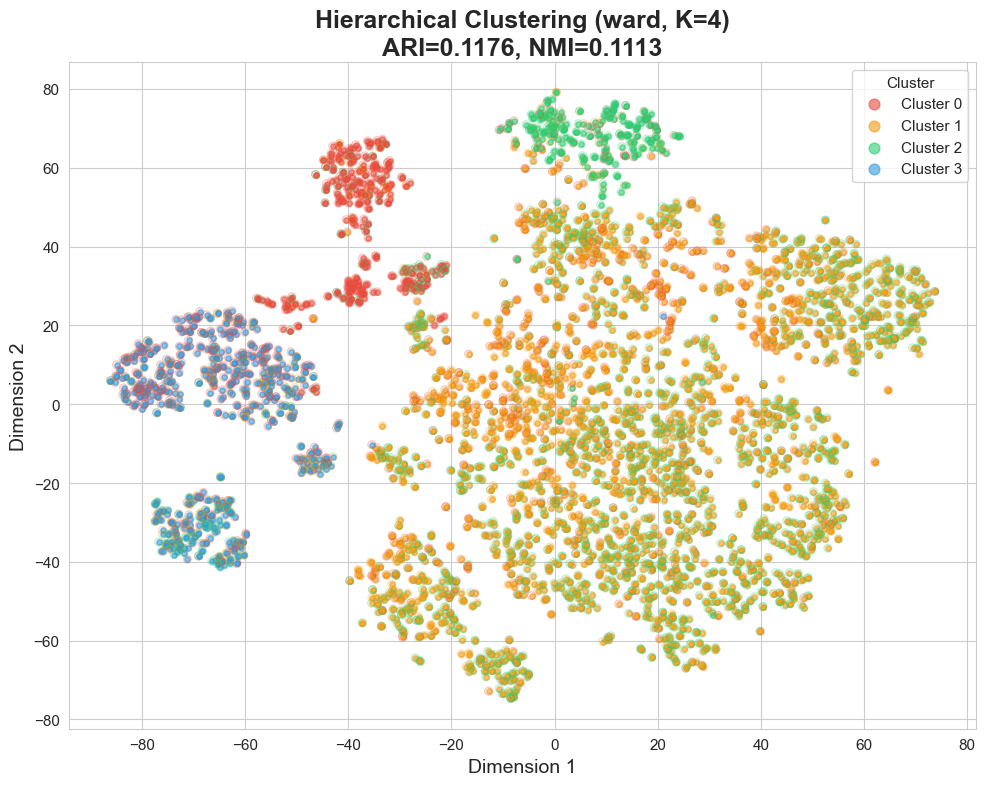

Hierarchical Cluster Size Distribution:
 Cluster  Count  Percentage
       0    331         7.5
       1   3195        72.2
       2    242         5.5
       3    656        14.8
Plot saved to /media/appleblue17/E/vscode/Assignments/2026Spring/ML/2026.04.27 Final Project/dsaa2011_machine_learning/data/plots/03_dendrogram_ward.png


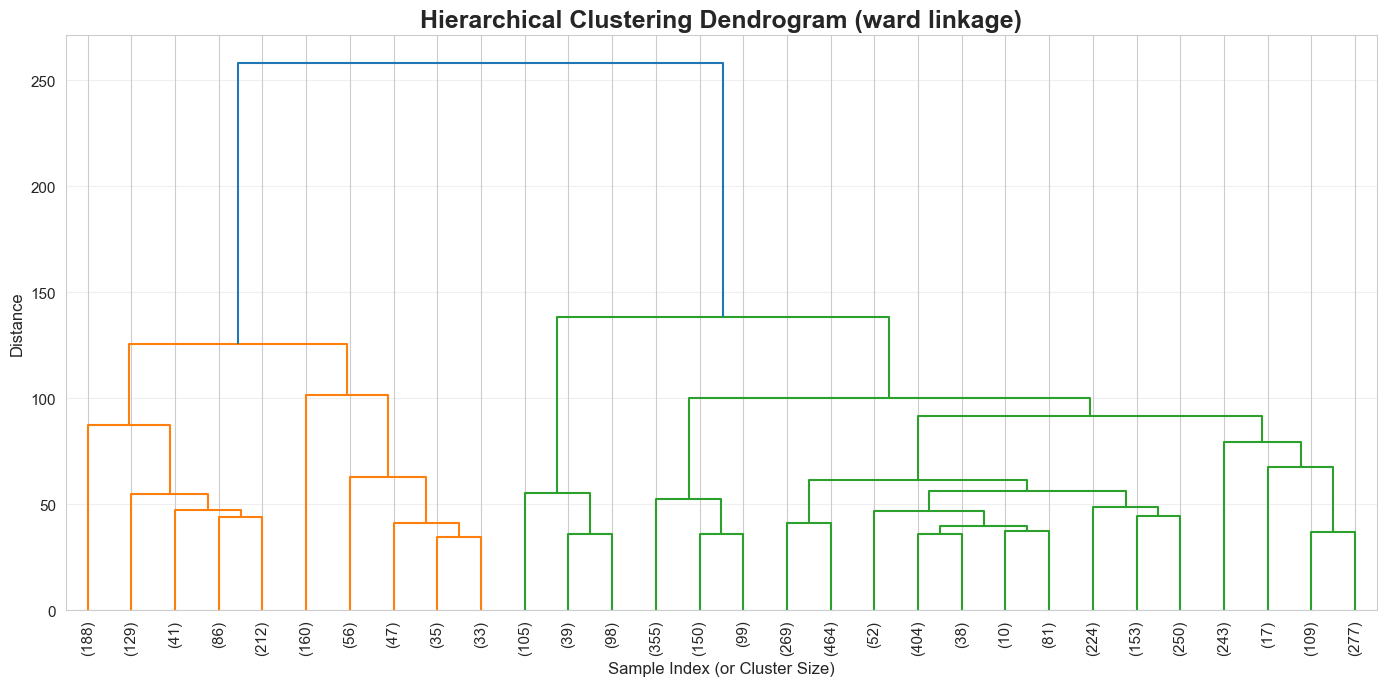


Hierarchical Clusters vs True Classes:
True Class    0    1     2
Cluster                   
0           261   21    49
1           651  654  1890
2            56   38   148
3           453   81   122

Dominant Class per Cluster:
  Cluster 0: Dropout (78.9%)
  Cluster 1: Graduate (59.2%)
  Cluster 2: Graduate (61.2%)
  Cluster 3: Dropout (69.1%)


In [9]:
# Hierarchical Clustering with best K and linkage
best_hier_k = 4
agg_labels = hierarchical_results[best_hier_k]["labels"]
agg_metrics = hierarchical_results[best_hier_k]["metrics"]

print(f"Hierarchical Clustering ({best_linkage}, K={best_hier_k}) Metrics:")
for name, value in agg_metrics.items():
    print(f"  {name}: {value:.4f}" if isinstance(value, float) else f"  {name}: {value}")

# Plot clusters on tsne
save_path = os.path.join(project_root, "data", "plots", "03_hierarchical_clusters_tsne.png")
ax = plot_cluster_scatter(tsne_embedding, agg_labels, title=f"Hierarchical Clustering ({best_linkage}, K={best_hier_k})\nARI={agg_metrics['adjusted_rand_index']:.4f}, NMI={agg_metrics['normalized_mutual_info']:.4f}", y_true=y.values, save_path=save_path)
plt.show()

# Hierarchical cluster size distribution table
agg_cluster_sizes = pd.Series(agg_labels).value_counts().sort_index()
agg_size_df = pd.DataFrame({
    "Cluster": agg_cluster_sizes.index,
    "Count": agg_cluster_sizes.values,
    "Percentage": (agg_cluster_sizes.values / len(y) * 100).round(1)
})
print("Hierarchical Cluster Size Distribution:")
print(agg_size_df.to_string(index=False))

# Hierarchical Clustering Dendrogram (best linkage)

from src.clustering import plot_dendrogram
fig = plot_dendrogram(
    X.values,
    method=best_linkage,
    save_path=os.path.join(project_root, "data", "plots", "03_dendrogram_ward.png"),
)
plt.show()

# Hierarchical cross-tabulation
agg_crosstab = compare_clusters_to_classes(agg_labels, y.values)
print("\nHierarchical Clusters vs True Classes:")
print(agg_crosstab.to_string())

print("\nDominant Class per Cluster:")
for cluster in agg_crosstab.index:
    row = agg_crosstab.loc[cluster]
    dominant_class = row.idxmax()
    dominant_pct = row.max() / row.sum() * 100
    print(f"  Cluster {cluster}: {class_names[dominant_class]} ({dominant_pct:.1f}%)")

## 4.1 GMM K-Value and Covariance Exploration

We explore different K values (K=3,4,5,6) and covariance types (full, tied, diag, spherical) for GMM to find the optimal configuration.

In [10]:
# GMM K-Value and Covariance Exploration
from sklearn.mixture import GaussianMixture

print("GMM K-Value and Covariance Exploration:")
print(f"{'K':>3} | {'Cov':>10} | {'ARI':>8} | {'NMI':>8} | {'Silhouette':>10} | {'CH Index':>10} | {'DB Index':>10}")
print("-" * 75)

gmm_results = {}
best_gmm_config = None
best_gmm_ari = 0

for k in [3, 4, 5, 6]:
    for cov in ['full', 'tied', 'diag', 'spherical']:
        gmm = GaussianMixture(n_components=k, covariance_type=cov, random_state=42, n_init=5)
        labels = gmm.fit_predict(X.values)
        metrics = evaluate_clustering(X.values, labels, y.values)
        gmm_results[(k, cov)] = {"labels": labels, "metrics": metrics}
        ari = metrics.get('adjusted_rand_index', 0)
        nmi = metrics.get('normalized_mutual_info', 0)
        sil = metrics.get('silhouette', 0)
        ch = metrics.get('calinski_harabasz', 0)
        db = metrics.get('davies_bouldin', 0)
        print(f"{k:>3} | {cov:>10} | {ari:>8.4f} | {nmi:>8.4f} | {sil:>10.4f} | {ch:>10.2f} | {db:>10.4f}")


GMM K-Value and Covariance Exploration:
  K |        Cov |      ARI |      NMI | Silhouette |   CH Index |   DB Index
---------------------------------------------------------------------------
  3 |       full |   0.1493 |   0.1124 |     0.1829 |     663.79 |     3.2906
  3 |       tied |   0.2485 |   0.1742 |     0.1525 |     757.30 |     2.3873
  3 |       diag |   0.2502 |   0.1734 |     0.1692 |     724.96 |     2.7425
  3 |  spherical |   0.1493 |   0.1064 |     0.1876 |     741.03 |     2.7159
  4 |       full |   0.0949 |   0.0924 |     0.1396 |     553.21 |     2.9372
  4 |       tied |   0.2270 |   0.1597 |     0.1697 |     678.75 |     2.1498
  4 |       diag |   0.2104 |   0.1485 |     0.1559 |     638.14 |     2.3662
  4 |  spherical |   0.1680 |   0.1196 |     0.1757 |     695.33 |     2.2420
  5 |       full |   0.1490 |   0.1085 |     0.0970 |     513.67 |     2.8182
  5 |       tied |   0.2294 |   0.1634 |     0.1429 |     568.84 |     2.1972
  5 |       diag |   0.121

GMM (K=4, covariance=tied) Metrics:
  silhouette: 0.1697
  silhouette_std: 0.1113
  calinski_harabasz: 678.7479
  davies_bouldin: 2.1498
  noise_ratio: 0.0000
  adjusted_rand_index: 0.2270
  normalized_mutual_info: 0.1597
Plot saved to /media/appleblue17/E/vscode/Assignments/2026Spring/ML/2026.04.27 Final Project/dsaa2011_machine_learning/data/plots/03_gmm_clusters_tsne.png


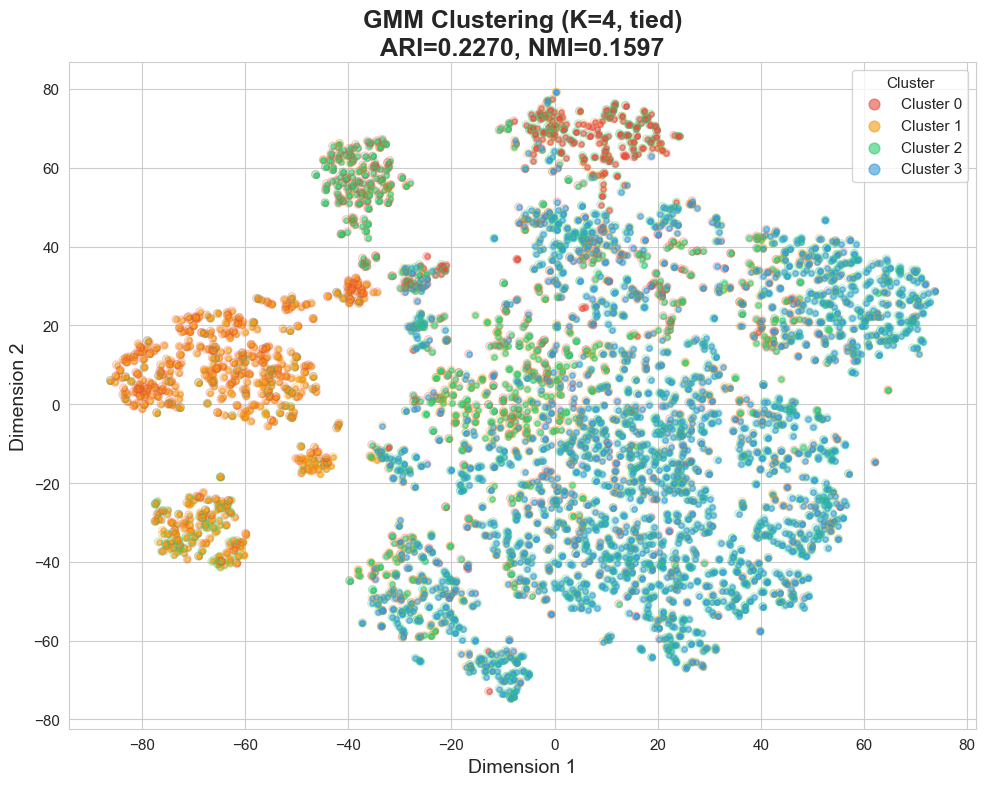


Cluster probabilities (first 5 points):
[[0.    0.    0.022 0.978]
 [0.    0.    0.    1.   ]
 [0.    0.    0.    1.   ]
 [0.    0.    0.895 0.105]
 [0.    0.    0.    1.   ]]

GMM Clusters vs True Classes:
True Class    0    1     2
Cluster                   
0            54   32   153
1           525   84   129
2           453  214    98
3           389  464  1829

Dominant Class per Cluster:
  Cluster 0: Graduate (64.0%)
  Cluster 1: Dropout (71.1%)
  Cluster 2: Dropout (59.2%)
  Cluster 3: Graduate (68.2%)


In [11]:
# GMM with best configuration (K=4, tied covariance)
gmm_labels = gmm_results[(4, 'tied')]["labels"]
gmm_metrics = gmm_results[(4, 'tied')]["metrics"]
gmm_k = 4
best_gmm_cov = 'tied'

print(f"GMM (K={gmm_k}, covariance={best_gmm_cov}) Metrics:")
for name, value in gmm_metrics.items():
    print(f"  {name}: {value:.4f}" if isinstance(value, float) else f"  {name}: {value}")

# Plot GMM clusters on tsne
save_path = os.path.join(project_root, "data", "plots", "03_gmm_clusters_tsne.png")
ax = plot_cluster_scatter(
    tsne_embedding, gmm_labels,
    title=f"GMM Clustering (K={gmm_k}, {best_gmm_cov})\nARI={gmm_metrics['adjusted_rand_index']:.4f}, NMI={gmm_metrics['normalized_mutual_info']:.4f}",
    y_true=y.values, save_path=save_path
)
plt.show()

# Cluster probabilities (sample of first 5 points)
from sklearn.mixture import GaussianMixture
gmm_model = GaussianMixture(n_components=gmm_k, covariance_type=best_gmm_cov, random_state=42, n_init=5)
gmm_model.fit(X.values)
gmm_probs = gmm_model.predict_proba(X.values)
print(f"\nCluster probabilities (first 5 points):")
print(gmm_probs[:5].round(3))

# GMM cross-tabulation
gmm_crosstab = compare_clusters_to_classes(gmm_labels, y.values)
print("\nGMM Clusters vs True Classes:")
print(gmm_crosstab.to_string())

print("\nDominant Class per Cluster:")
for cluster in gmm_crosstab.index:
    row = gmm_crosstab.loc[cluster]
    dominant_class = row.idxmax()
    dominant_pct = row.max() / row.sum() * 100
    print(f"  Cluster {cluster}: {class_names[dominant_class]} ({dominant_pct:.1f}%)")